In [ ]:
%pip install --upgrade jupyter ipywidgets
%jupyter nbextension enable --py widgetsnbextension

In [60]:
import seaborn as sns
import pandas as pd
import altair as alt
import pathlib
import statsmodels.formula.api as smf
import tqdm.notebook as tqdm
import functools
import json

sns.set(font_scale=2) 
sns.set_style("whitegrid")

EXP1_GRPS = ['bcms_setimes', 'estonian_voro', 'scandinavian']
REMAPS = {
    'estonian_voro': 'EV', 
    'bcms_setimes': 'CS',
    'scandinavian': 'Scandi.',
}


In [61]:
records = []
for grp in EXP1_GRPS:
    for listname in pathlib.Path(f'../../lists/{grp}').glob('**/list.*'):
        data = pd.read_csv(listname)
        records.append({
            'list_name': str(listname), 
            '% falselist': data.in_blacklist.mean() if "in_blacklist" in data.columns else 0,
            **dict(kv.split('=') for kv in '.'.join(listname.name.split('.')[2:-1]).split('_')),
        })
df = pd.DataFrame.from_records(records)
df

,list_name,% falselist,attrib,mpd,thresh,docnorm,tfidf
0,../../lists/bcms_setimes/list.bcms_setimes.att...,0.8450,loo,20,0.8,F,F
1,../../lists/bcms_setimes/list.bcms_setimes.att...,0.8150,lime,18,0.5,F,F
2,../../lists/bcms_setimes/list.bcms_setimes.att...,0.7950,shap,18,0.1,F,T
3,../../lists/bcms_setimes/list.bcms_setimes.att...,0.8200,shap,19,0.8,F,F
4,../../lists/bcms_setimes/list.bcms_setimes.att...,0.6400,loo,2,0.9,T,T
...,...,...,...,...,...,...,...
9595,../../lists/scandinavian/list.scandinavian.att...,0.5250,lime,11,1.0,T,F
9596,../../lists/scandinavian/list.scandinavian.att...,0.4725,loo,1,0.5,T,F
9597,../../lists/scandinavian/list.scandinavian.att...,0.2925,lime,7,0.5,T,T
9598,../../lists/scandinavian/list.scandinavian.att...,0.6750,shap,20,0.9,F,F


In [62]:
df['Group'] = df.list_name.apply(lambda lstnm: lstnm.split('/')[-2]).map(REMAPS)
df['Attribution'] = df.attrib.str.upper()
df['m'] = df.mpd.apply(int)
df['p'] = df.thresh.apply(float)
df['avg'] = df.docnorm == 'T'
df['tfidf'] = df.tfidf == 'T'
df['falselist'] = df['% falselist']
df

,list_name,% falselist,attrib,mpd,thresh,docnorm,tfidf,Group,Attribution,m,p,avg,falselist
0,../../lists/bcms_setimes/list.bcms_setimes.att...,0.8450,loo,20,0.8,F,False,CS,LOO,20,0.8,False,0.8450
1,../../lists/bcms_setimes/list.bcms_setimes.att...,0.8150,lime,18,0.5,F,False,CS,LIME,18,0.5,False,0.8150
2,../../lists/bcms_setimes/list.bcms_setimes.att...,0.7950,shap,18,0.1,F,True,CS,SHAP,18,0.1,False,0.7950
3,../../lists/bcms_setimes/list.bcms_setimes.att...,0.8200,shap,19,0.8,F,False,CS,SHAP,19,0.8,False,0.8200
4,../../lists/bcms_setimes/list.bcms_setimes.att...,0.6400,loo,2,0.9,T,True,CS,LOO,2,0.9,True,0.6400
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,../../lists/scandinavian/list.scandinavian.att...,0.5250,lime,11,1.0,T,False,Scandi.,LIME,11,1.0,True,0.5250
9596,../../lists/scandinavian/list.scandinavian.att...,0.4725,loo,1,0.5,T,False,Scandi.,LOO,1,0.5,True,0.4725
9597,../../lists/scandinavian/list.scandinavian.att...,0.2925,lime,7,0.5,T,True,Scandi.,LIME,7,0.5,True,0.2925
9598,../../lists/scandinavian/list.scandinavian.att...,0.6750,shap,20,0.9,F,False,Scandi.,SHAP,20,0.9,False,0.6750


In [ ]:
# CAUTION: this runs pairwise comparisons between all lists, so takes quite a long time to run
# `df_overlaps` is not used for any visualizations further below, so this cell (and the two following ones) can be skipped

def iou(obs_a, obs_b):
    obs_a, obs_b = set(obs_a), set(obs_b)
    return len(obs_a & obs_b) / len(obs_a | obs_b)

records = []


@functools.lru_cache(3200)
def pd_read_csv(fname):
    return pd.read_csv(fname)

for lang_grp, subdf in tqdm.tqdm(df.groupby('Group')):
    files = subdf.list_name.to_list()
    with tqdm.trange((len(files) * (len(files) - 1)) // 2, leave=False) as pbar:
        for idx, filea in enumerate(files[:-1], start=1):
            data_a = pd_read_csv(filea)
            for fileb in files[idx:]:
                data_b = pd_read_csv(fileb)
                records.append({
                    'file_a': filea,
                    'file_b': fileb,
                    # 'ious_per_label': {
                    #     label: iou(data_a[data_a.label == label].token, data_b[data_b.label == label].token) 
                    #     for label in data_a.label.unique()
                    # },
                    'global_iou': iou(data_a.token, data_b.token),
                })
                pbar.update()

df_overlaps = pd.DataFrame.from_records(records)
df_overlaps

In [ ]:
df_overlaps['Group'] = df_overlaps.file_a.apply(lambda lstnm: lstnm.split('/')[-2]).map(REMAPS)
df_overlaps['Attribution'] = df_overlaps.file_a.apply(lambda fname: fname.split('/')[-1].split('.', 2)[-1][:-len('.csv')].split('_')[0][len('attrib='):].upper())
df_overlaps['Attribution_b'] = df_overlaps.file_b.apply(lambda fname: fname.split('/')[-1].split('.', 2)[-1][:-len('.csv')].split('_')[0][len('attrib='):].upper())
df_overlaps

In [ ]:
g = sns.kdeplot(
    data=df_overlaps[(df_overlaps.Group == 'EV') & (df_overlaps.Attribution == df_overlaps.Attribution_b)], 
    x='global_iou',
    hue='Attribution',
)


In [63]:
def read_json(fname):
    with open(fname, 'r') as istr:
        return json.load(istr)

FREQ_FILES = {
    grp: {
        fname.name.split('.')[2]: read_json(fname) 
        for fname in pathlib.Path('freqs').glob('*.json') 
        if grp in fname.name
    }
    for grp in EXP1_GRPS
}

totals = {
    grp: {
        lbl: sum(FREQ_FILES[grp][lbl].values()) 
         for lbl in FREQ_FILES[grp]
    } 
    for grp in FREQ_FILES
}

FREQ_FILES = {
    REMAPS[grp]: {
        lbl: {
            k: v/ totals[grp][lbl]
            for k, v in FREQ_FILES[grp][lbl].items()
        }
        for lbl in FREQ_FILES[grp]
    }
    for grp in FREQ_FILES
}

all_data = []
for grp in EXP1_GRPS:
    for listname in pathlib.Path(f'../../lists/{grp}').glob('**/list.*'):
        all_data.append(pd.read_csv(listname))
        all_data[-1]['list_name'] = str(listname)

df_allinfo = pd.concat(all_data)
del all_data
df_allinfo['Group'] = df_allinfo.list_name.apply(lambda lstnm: lstnm.split('/')[3]).map(REMAPS)
df_allinfo = df_allinfo.groupby(['token', 'Group', 'label']).size().reset_index().rename(columns={0:'how_often'})
df_allinfo['freq'] = df_allinfo.apply(lambda row: FREQ_FILES[row['Group']][row['label']].get(row['token'], 0), axis=1)
df_allinfo

,token,Group,label,how_often,freq
0,"0,7",CS,hr,8,0.000005
1,08,EV,vro,19,0.000021
2,1,EV,est,29,0.000145
3,1,Scandi.,nn,45,0.000100
4,10,CS,hr,1,0.000157
...,...,...,...,...,...
17520,„šišanje“,CS,sr,1,0.000000
17521,„šta,CS,sr,47,0.000000
17522,„šteta,CS,sr,156,0.000000
17523,„žalba,CS,sr,15,0.000000


In [64]:
import scipy.stats
for ident, subdf in df_allinfo[df_allinfo.freq != 0].groupby(['Group', 'label']):
    print(*ident, *scipy.stats.spearmanr(subdf.how_often, subdf.freq), sep=' & ', end ='\\\\\n')


CS & hr & 0.13237655209784566 & 1.1875569895560692e-11\\
CS & sr & 0.1795175687904212 & 3.861667770377295e-18\\
EV & est & 0.3464941724185743 & 2.3480168298841896e-54\\
EV & vro & 0.34119524667852225 & 3.0071838523219032e-55\\
Scandi. & da & 0.30591003588851146 & 1.308412505236757e-41\\
Scandi. & nb & 0.33765717127545697 & 1.1458687044984364e-49\\
Scandi. & nn & 0.32074720409786783 & 1.5830342613720054e-41\\
Scandi. & sv & 0.26430993283018994 & 1.937978072192047e-29\\


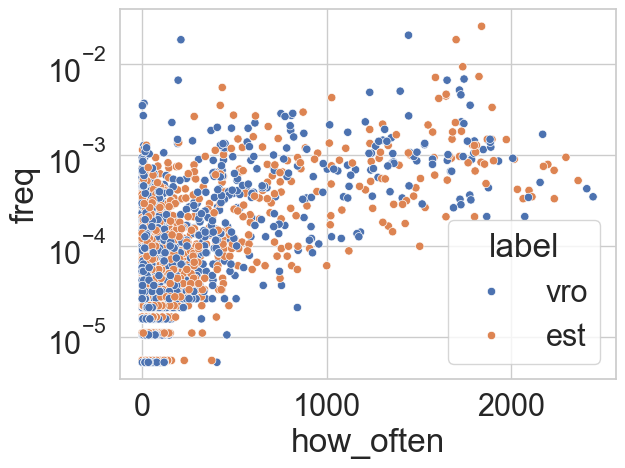

In [65]:
g = sns.scatterplot(data=df_allinfo[df_allinfo.Group=='EV'], hue='label', x='how_often', y='freq')
g.set_yscale("log")

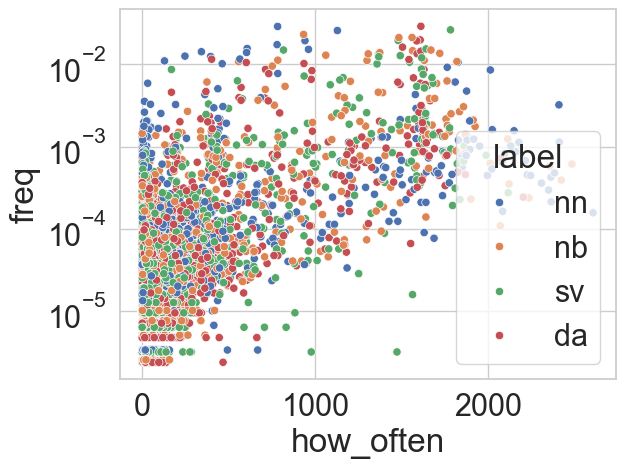

In [66]:
g = sns.scatterplot(data=df_allinfo[df_allinfo.Group=='Scandi.'], hue='label', x='how_often', y='freq')
g.set_yscale("log")

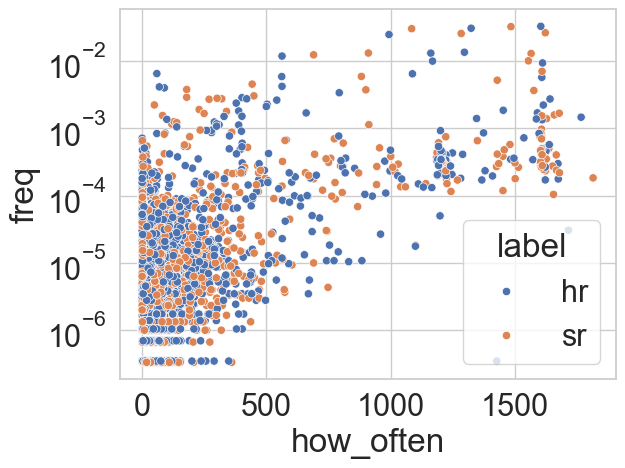

In [67]:
g = sns.scatterplot(data=df_allinfo[df_allinfo.Group=='CS'], hue='label', x='how_often', y='freq')
g.set_yscale("log")

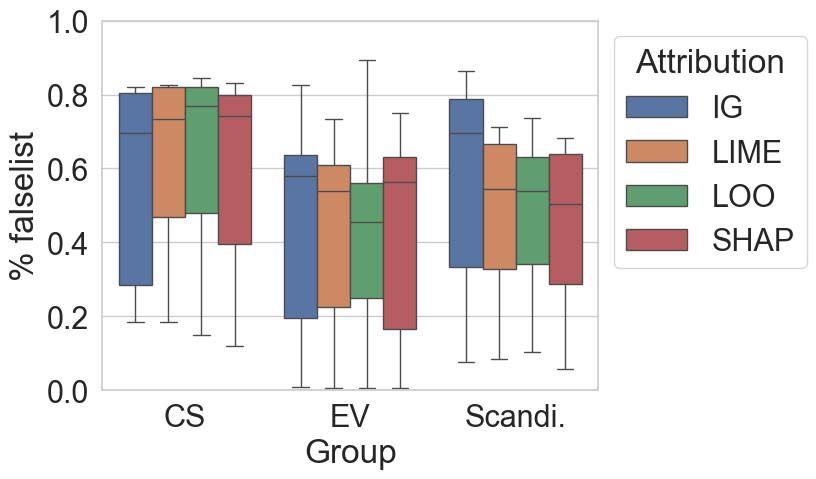

In [68]:
g = sns.boxplot(data=df, x='Group', y='% falselist', hue='Attribution', hue_order=sorted(df.Attribution.unique()), dodge=True)
g.set(ylim=(0,1))
sns.move_legend(g, "upper left", bbox_to_anchor=(1, 1))
g.get_figure().savefig('prop_falselist.pdf', bbox_inches='tight')

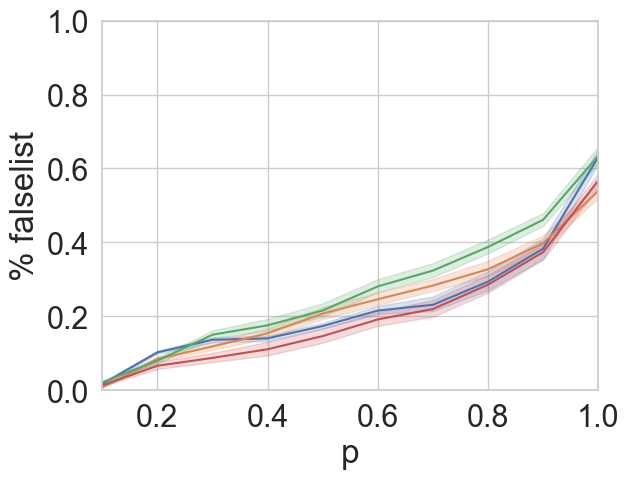

In [69]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'EV')], y='% falselist', x='p', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(0.1,1.0))
g.get_figure().savefig('falselist_v_p.ev.pdf', bbox_inches='tight')

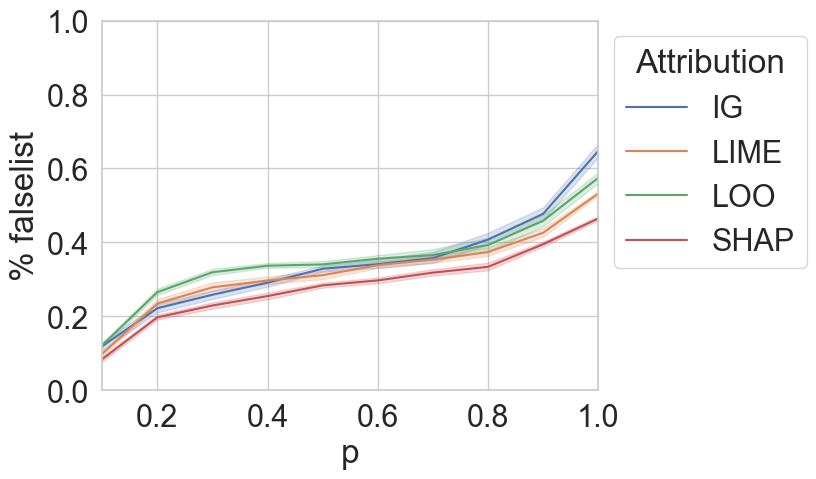

In [70]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'Scandi.')], y='% falselist', x='p', hue='Attribution', hue_order=sorted(df.Attribution.unique()))
sns.move_legend(g, 'upper left', bbox_to_anchor=(1, 1))
g.set(ylim=(0,1), xlim=(0.1,1.0))
g.get_figure().savefig('falselist_v_p.scandi.pdf', bbox_inches='tight')

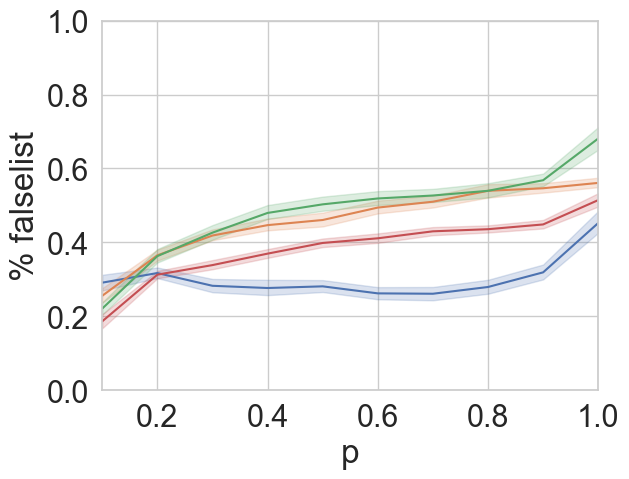

In [71]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'CS')], y='% falselist', x='p', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(0.1,1.0))
g.get_figure().savefig('falselist_v_p.cs.pdf', bbox_inches='tight')

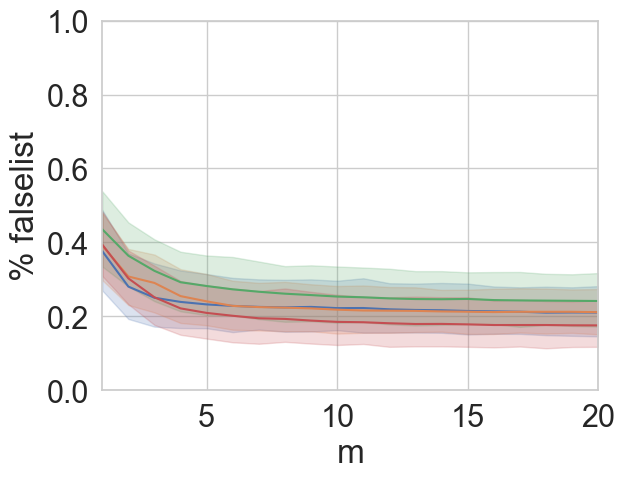

In [72]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'EV')], y='% falselist', x='m', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(1, 20))
g.get_figure().savefig('falselist_v_m.ev.pdf', bbox_inches='tight')

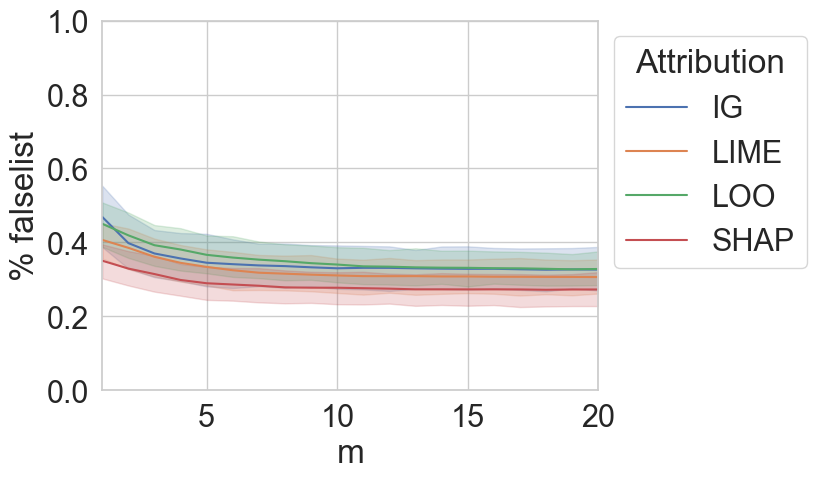

In [73]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'Scandi.')], y='% falselist', x='m', hue='Attribution', hue_order=sorted(df.Attribution.unique()))
sns.move_legend(g, 'upper left', bbox_to_anchor=(1, 1))
g.set(ylim=(0,1), xlim=(1, 20))
g.get_figure().savefig('falselist_v_m.scandi.pdf', bbox_inches='tight')

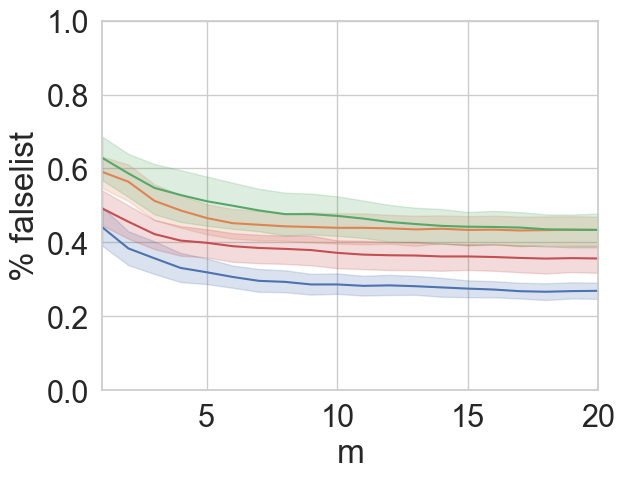

In [74]:
g = sns.lineplot(data=df[(df.docnorm == 'T') & (df.Group == 'CS')], y='% falselist', x='m', hue='Attribution', hue_order=sorted(df.Attribution.unique()), legend=False)
g.set(ylim=(0,1), xlim=(1, 20))
g.get_figure().savefig('falselist_v_m.bcms_s.pdf', bbox_inches='tight')

In [75]:
def do_bnorm(obs):
    obs = obs.apply(int)
    return ((obs - obs.min()) / (obs.max() - obs.min())) -0.5

def do_norm(obs):
    return ((obs - obs.min()) / (obs.max() - obs.min())) -0.5

res = smf.ols(
    'falselist ~ C(Attribution) + C(Group) + do_bnorm(tfidf) + do_bnorm(avg) + do_norm(m) + do_norm(p)', 
    data = df,
).fit()
sumry = res.summary()
sumry

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              falselist   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     5910.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        09:01:01   Log-Likelihood:                 9557.7
No. Observations:                9600   AIC:                        -1.910e+04
Df Residuals:                    9590   BIC:                        -1.902e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0.6131      0.002    274.142      0.000       0.609       0.617
C(Attribution)[T.LIME]     0.0036      0.003      1.391      0.164      -0.001       0.009
C(Attribution)[T.LOO]     -0.0015      0.003     -0.590      0.555      -0.007       0.004
C(Attribution)[T.SHAP]    -0.0230      0.003     -8.918      0.000      -0.028      -0.018
C(Group)[T.EV]            -0.1937      0.002    -86.607      0.000      -0.198      -0.189
C(Group)[T.Scandi.]       -0.1055      0.002    -47.179      0.000      -0.110      -0.101
do_bnorm(tfidf)           -0.0158      0.002     -8.672      0.000      -0.019      -0.012
do_bnorm(avg)             -0.3685      0.002   -201.799      0.000      -0.372      -0.365
do_norm(m)                -0.0392      0.003    -13.036      0.000      -0.045      -0.033
do_norm(p)                 0.1933      0.003     67.576      0.000       0.188       0.199
==============================================================================
Omnibus:                      733.472   Durbin-Watson:                   2.050
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1432.578
Skew:                           0.529   Prob(JB):                    8.31e-312
Kurtosis:                       4.569   Cond. No.                         5.35
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [76]:
print(sumry.tables[1].as_latex_tabular())

\begin{center}
\begin{tabular}{lcccccc}
\toprule
                                & \textbf{coef} & \textbf{std err} & \textbf{t} & \textbf{P$> |$t$|$} & \textbf{[0.025} & \textbf{0.975]}  \\
\midrule
\textbf{Intercept}              &       0.6131  &        0.002     &   274.142  &         0.000        &        0.609    &        0.617     \\
\textbf{C(Attribution)[T.LIME]} &       0.0036  &        0.003     &     1.391  &         0.164        &       -0.001    &        0.009     \\
\textbf{C(Attribution)[T.LOO]}  &      -0.0015  &        0.003     &    -0.590  &         0.555        &       -0.007    &        0.004     \\
\textbf{C(Attribution)[T.SHAP]} &      -0.0230  &        0.003     &    -8.918  &         0.000        &       -0.028    &       -0.018     \\
\textbf{C(Group)[T.EV]}         &      -0.1937  &        0.002     &   -86.607  &         0.000        &       -0.198    &       -0.189     \\
\textbf{C(Group)[T.Scandi.]}    &      -0.1055  &        0.002     &   -47.179  &    

In [77]:
res.params

Intercept                 0.613089
C(Attribution)[T.LIME]    0.003593
C(Attribution)[T.LOO]    -0.001523
C(Attribution)[T.SHAP]   -0.023029
C(Group)[T.EV]           -0.193686
C(Group)[T.Scandi.]      -0.105511
do_bnorm(tfidf)          -0.015836
do_bnorm(avg)            -0.368486
do_norm(m)               -0.039218
do_norm(p)                0.193322
dtype: float64

In [78]:
df = pd.read_csv('../../lists/scandinavian_lists_overview.csv')
for idx, hparam in enumerate(['attrib', 'mdp', 'thresh', 'docnorm', 'tfidf']):
    df[hparam] = df.fname.apply(lambda fname: fname[:-len('.csv')].split('.', 2)[2].split('_')[idx][len(hparam)+1:])
df['mdp'] = df.mdp.apply(int)
df['thresh'] = df.thresh.apply(float)
df1 = df
df

,prop_wl,prop_bl,prop_happaxes,prop_lt2,prop_lt3,prop_lt4,prop_lt5,num_extracted,fname,attrib,mdp,thresh,docnorm,tfidf
0,0.657500,0.322500,0.00,0.0000,0.0000,0.0000,0.0000,400,lists/scandinavian/list.scandinavian.attrib=sh...,shap,15,0.8,T,F
1,0.440000,0.537500,0.00,0.0075,0.0125,0.0150,0.0175,400,lists/scandinavian/list.scandinavian.attrib=lo...,loo,18,0.1,F,T
2,0.315000,0.675000,0.00,0.0025,0.0025,0.0025,0.0025,400,lists/scandinavian/list.scandinavian.attrib=sh...,shap,18,0.1,F,F
3,0.460000,0.120000,0.75,0.9100,0.9550,0.9625,0.9675,400,lists/scandinavian/list.scandinavian.attrib=li...,lime,4,0.1,T,F
4,0.440000,0.537500,0.00,0.0075,0.0125,0.0150,0.0175,400,lists/scandinavian/list.scandinavian.attrib=lo...,loo,20,0.1,F,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,0.182500,0.810000,0.00,0.0025,0.0025,0.0025,0.0025,400,lists/scandinavian/list.scandinavian.attrib=ig...,ig,15,1.0,F,F
3196,0.537500,0.442500,0.00,0.0000,0.0000,0.0000,0.0000,400,lists/scandinavian/list.scandinavian.attrib=lo...,loo,11,0.9,T,F
3197,0.446194,0.545932,0.00,0.0000,0.0000,0.0000,0.0000,381,lists/scandinavian/list.scandinavian.attrib=li...,lime,1,0.9,T,F
3198,0.330000,0.662500,0.00,0.0000,0.0000,0.0000,0.0000,400,lists/scandinavian/list.scandinavian.attrib=li...,lime,20,0.6,F,T


<Axes: xlabel='prop_bl', ylabel='thresh'>

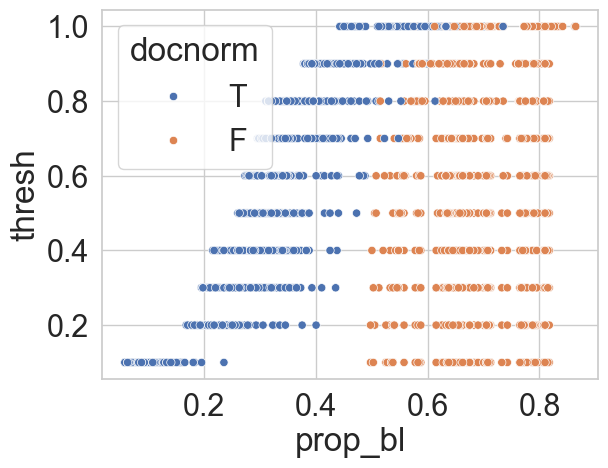

In [79]:
sns.scatterplot(data=df1, x='prop_bl', y='thresh', hue='docnorm')

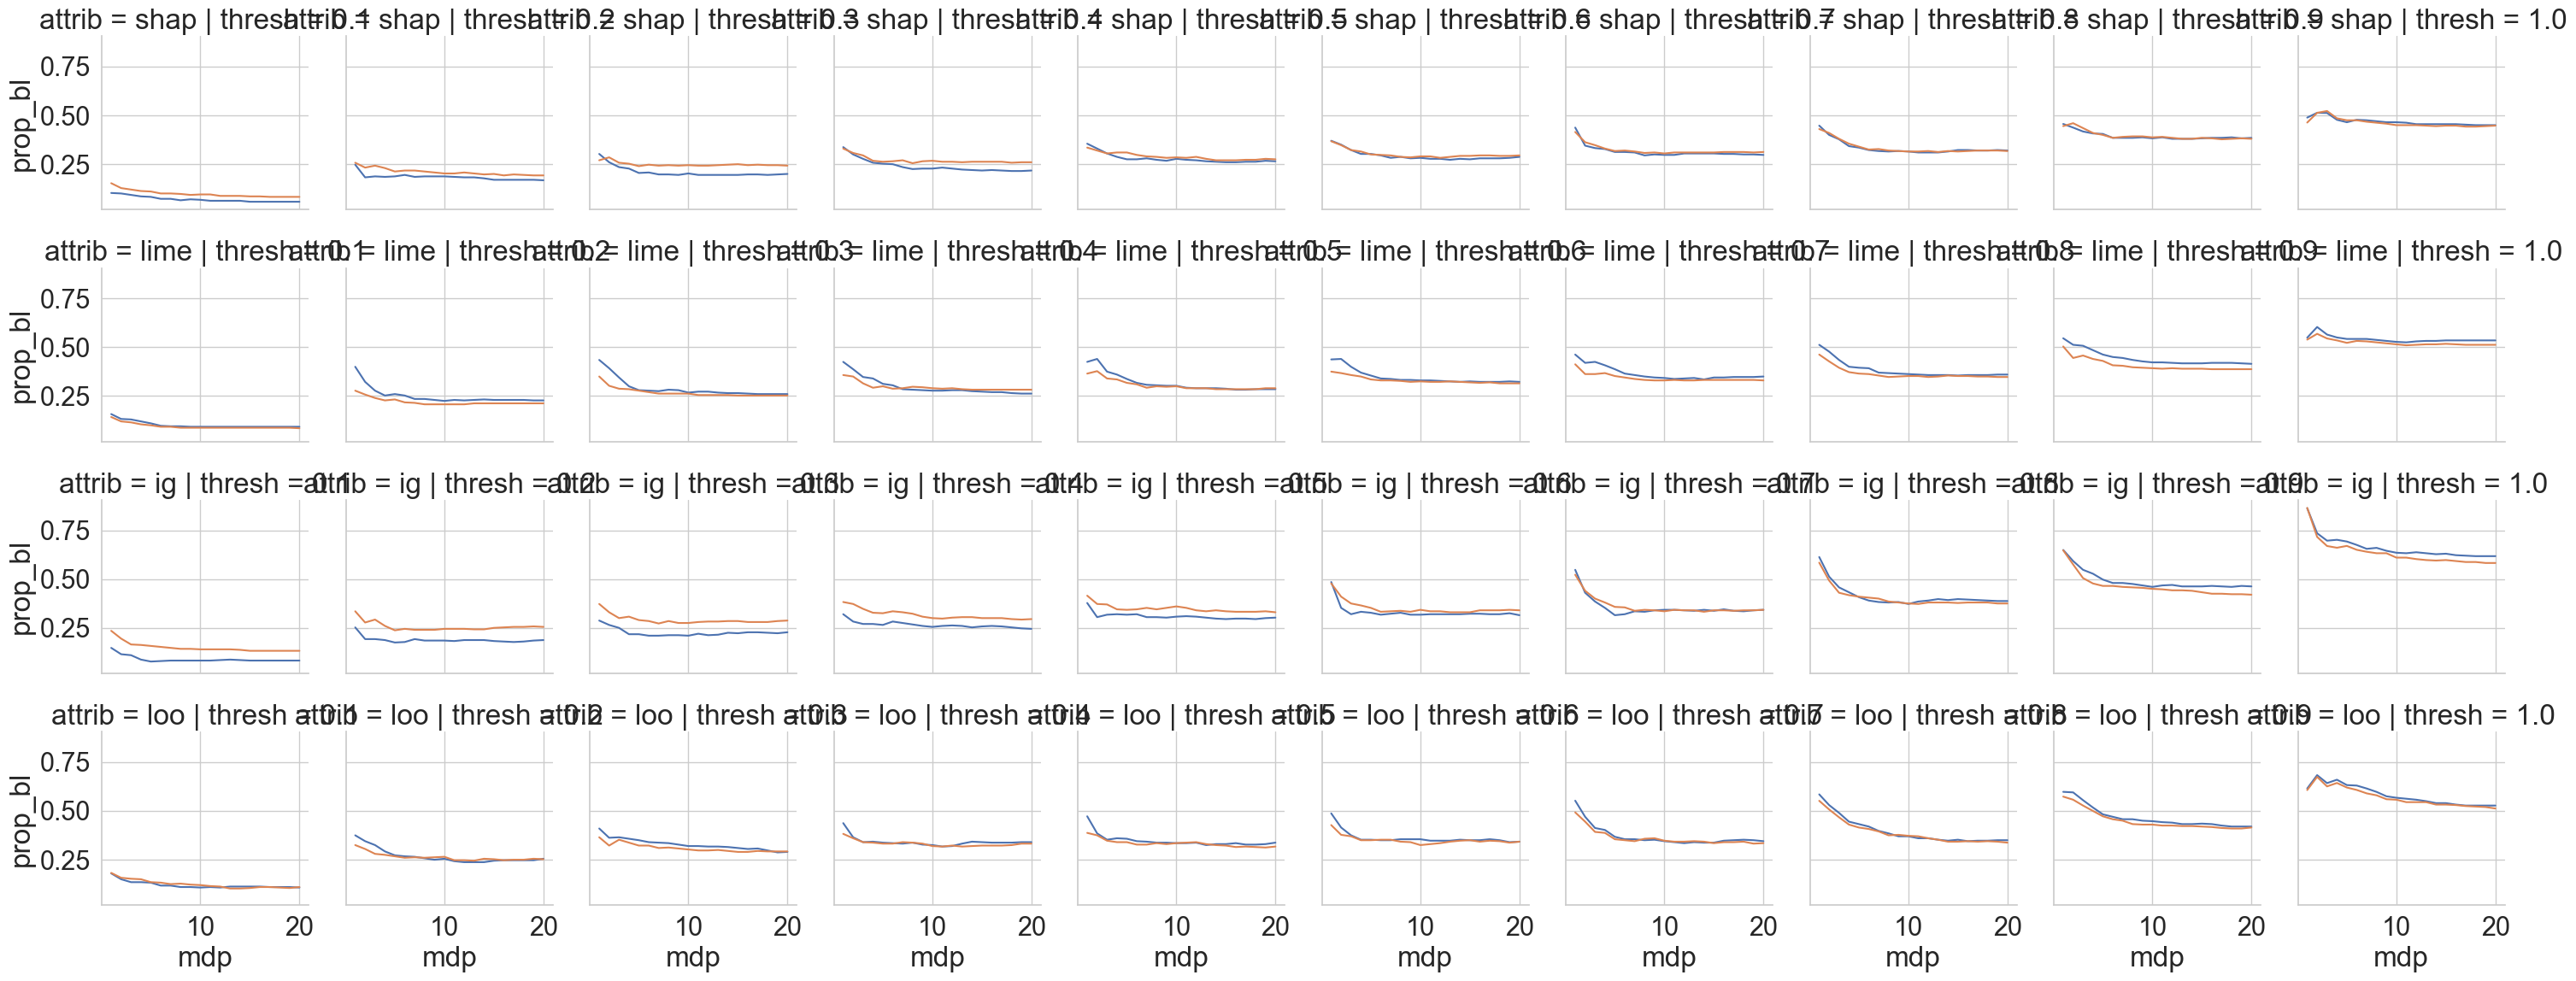

In [80]:
df['norm_setup'] =  df.apply(lambda row: row['docnorm'] + row['tfidf'], axis=1)
g = sns.FacetGrid(data=df[df.docnorm == 'T'], row='attrib', col='thresh', hue='norm_setup')
g.map(sns.lineplot, 'mdp', 'prop_bl')

<Axes: xlabel='thresh', ylabel='prop_lt5'>

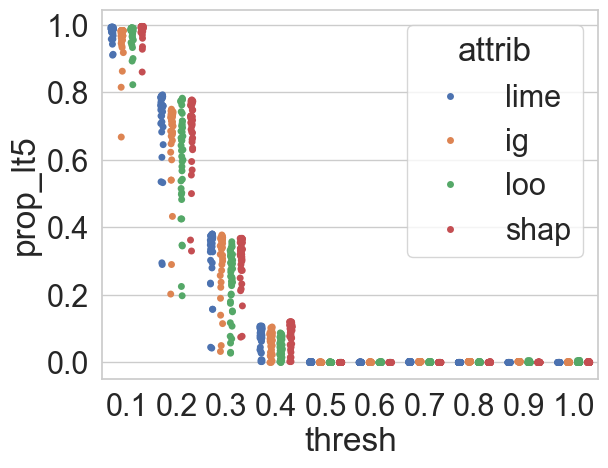

In [81]:
sns.stripplot(data=df[df.docnorm == 'T'], hue='attrib', x='thresh', y='prop_lt5', dodge=True)

In [82]:
df = pd.read_csv('../../lists/estonian_voro_lists_overview.csv')
for idx, hparam in enumerate(['attrib', 'mdp', 'thresh', 'docnorm', 'tfidf']):
    df[hparam] = df.fname.apply(lambda fname: fname[:-len('.csv')].split('.', 2)[2].split('_')[idx][len(hparam)+1:])
df['mdp'] = df.mdp.apply(int)
df['thresh'] = df.thresh.apply(float)
df2 = df
df

,prop_wl,prop_bl,prop_happaxes,prop_lt2,prop_lt3,prop_lt4,prop_lt5,num_extracted,fname,attrib,mdp,thresh,docnorm,tfidf
0,0.700,0.220,0.000,0.005,0.005,0.005,0.005,200,lists/estonian_voro/list.estonian_voro.attrib=...,ig,14,0.6,T,T
1,0.290,0.655,0.000,0.010,0.010,0.010,0.010,200,lists/estonian_voro/list.estonian_voro.attrib=...,ig,19,0.3,F,F
2,0.730,0.135,0.000,0.005,0.005,0.005,0.175,200,lists/estonian_voro/list.estonian_voro.attrib=...,lime,18,0.4,T,T
3,0.760,0.140,0.000,0.000,0.000,0.000,0.000,200,lists/estonian_voro/list.estonian_voro.attrib=...,shap,7,0.5,T,T
4,0.405,0.540,0.000,0.000,0.000,0.000,0.000,200,lists/estonian_voro/list.estonian_voro.attrib=...,shap,13,1.0,T,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,0.340,0.605,0.000,0.005,0.005,0.005,0.005,200,lists/estonian_voro/list.estonian_voro.attrib=...,loo,3,0.9,F,T
3196,0.375,0.555,0.005,0.005,0.005,0.005,0.005,200,lists/estonian_voro/list.estonian_voro.attrib=...,lime,5,0.3,F,T
3197,0.560,0.360,0.000,0.000,0.000,0.000,0.000,200,lists/estonian_voro/list.estonian_voro.attrib=...,lime,20,0.9,T,F
3198,0.340,0.580,0.000,0.000,0.000,0.000,0.000,200,lists/estonian_voro/list.estonian_voro.attrib=...,shap,19,0.3,F,T


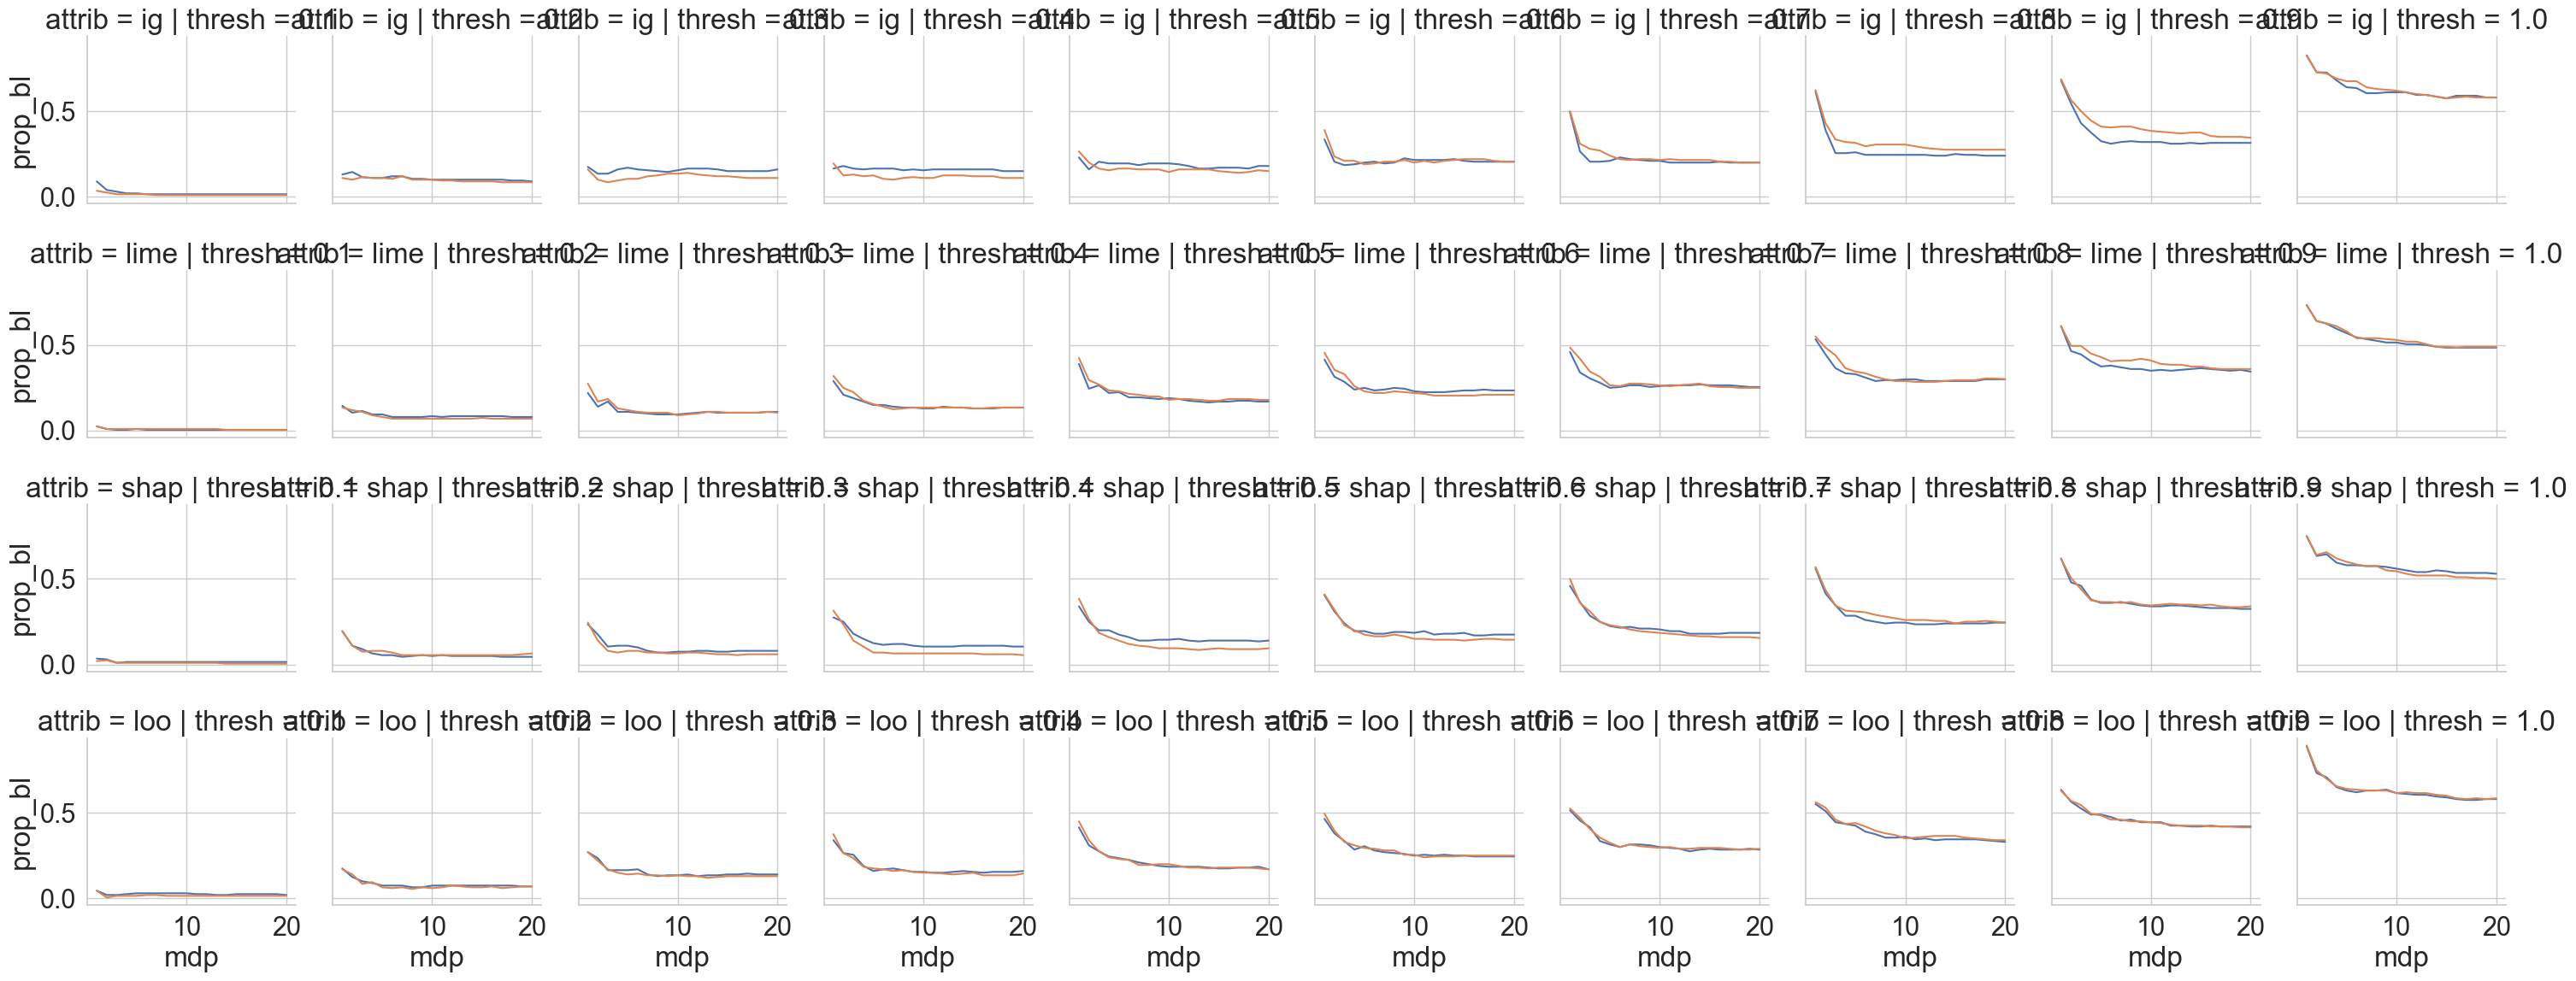

In [83]:
df['norm_setup'] =  df.apply(lambda row: row['docnorm'] + row['tfidf'], axis=1)
g = sns.FacetGrid(data=df[df.docnorm == 'T'], row='attrib', col='thresh', hue='norm_setup')
g.map(sns.lineplot, 'mdp', 'prop_bl')

<Axes: xlabel='thresh', ylabel='prop_lt5'>

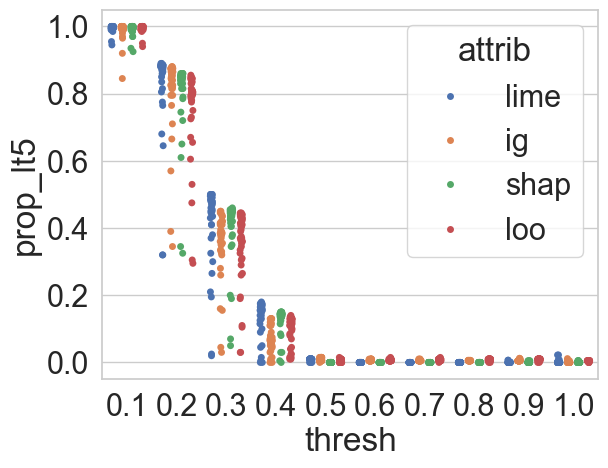

In [84]:
sns.stripplot(data=df[df.docnorm == 'T'], hue='attrib', x='thresh', y='prop_lt5', dodge=True)

In [85]:
df = pd.read_csv('../../lists/bcms_setimes_lists_overview.csv')
for idx, hparam in enumerate(['attrib', 'mdp', 'thresh', 'docnorm', 'tfidf']):
    df[hparam] = df.fname.apply(lambda fname: fname[:-len('.csv')].split('.', 2)[2].split('_')[idx][len(hparam)+1:])
df['mdp'] = df.mdp.apply(int)
df['thresh'] = df.thresh.apply(float)
df3 = df
df

,prop_wl,prop_bl,prop_happaxes,prop_lt2,prop_lt3,prop_lt4,prop_lt5,num_extracted,fname,attrib,mdp,thresh,docnorm,tfidf
0,0.180,0.780,0.000,0.035,0.035,0.035,0.035,200,lists/bcms_setimes/list.bcms_setimes.attrib=lo...,loo,3,0.2,F,T
1,0.330,0.550,0.000,0.100,0.100,0.100,0.100,200,lists/bcms_setimes/list.bcms_setimes.attrib=lo...,loo,15,0.9,T,T
2,0.180,0.820,0.000,0.000,0.000,0.000,0.000,200,lists/bcms_setimes/list.bcms_setimes.attrib=li...,lime,13,0.5,F,F
3,0.160,0.805,0.000,0.035,0.035,0.035,0.035,200,lists/bcms_setimes/list.bcms_setimes.attrib=lo...,loo,18,0.4,F,T
4,0.385,0.450,0.000,0.135,0.135,0.135,0.135,200,lists/bcms_setimes/list.bcms_setimes.attrib=sh...,shap,11,0.8,T,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,0.445,0.410,0.000,0.125,0.125,0.125,0.125,200,lists/bcms_setimes/list.bcms_setimes.attrib=sh...,shap,8,0.6,T,F
3196,0.385,0.585,0.000,0.000,0.000,0.000,0.000,200,lists/bcms_setimes/list.bcms_setimes.attrib=li...,lime,5,0.8,T,T
3197,0.435,0.470,0.000,0.075,0.075,0.075,0.075,200,lists/bcms_setimes/list.bcms_setimes.attrib=sh...,shap,18,1.0,T,T
3198,0.440,0.285,0.555,0.805,0.895,0.945,0.975,200,lists/bcms_setimes/list.bcms_setimes.attrib=li...,lime,11,0.1,T,T


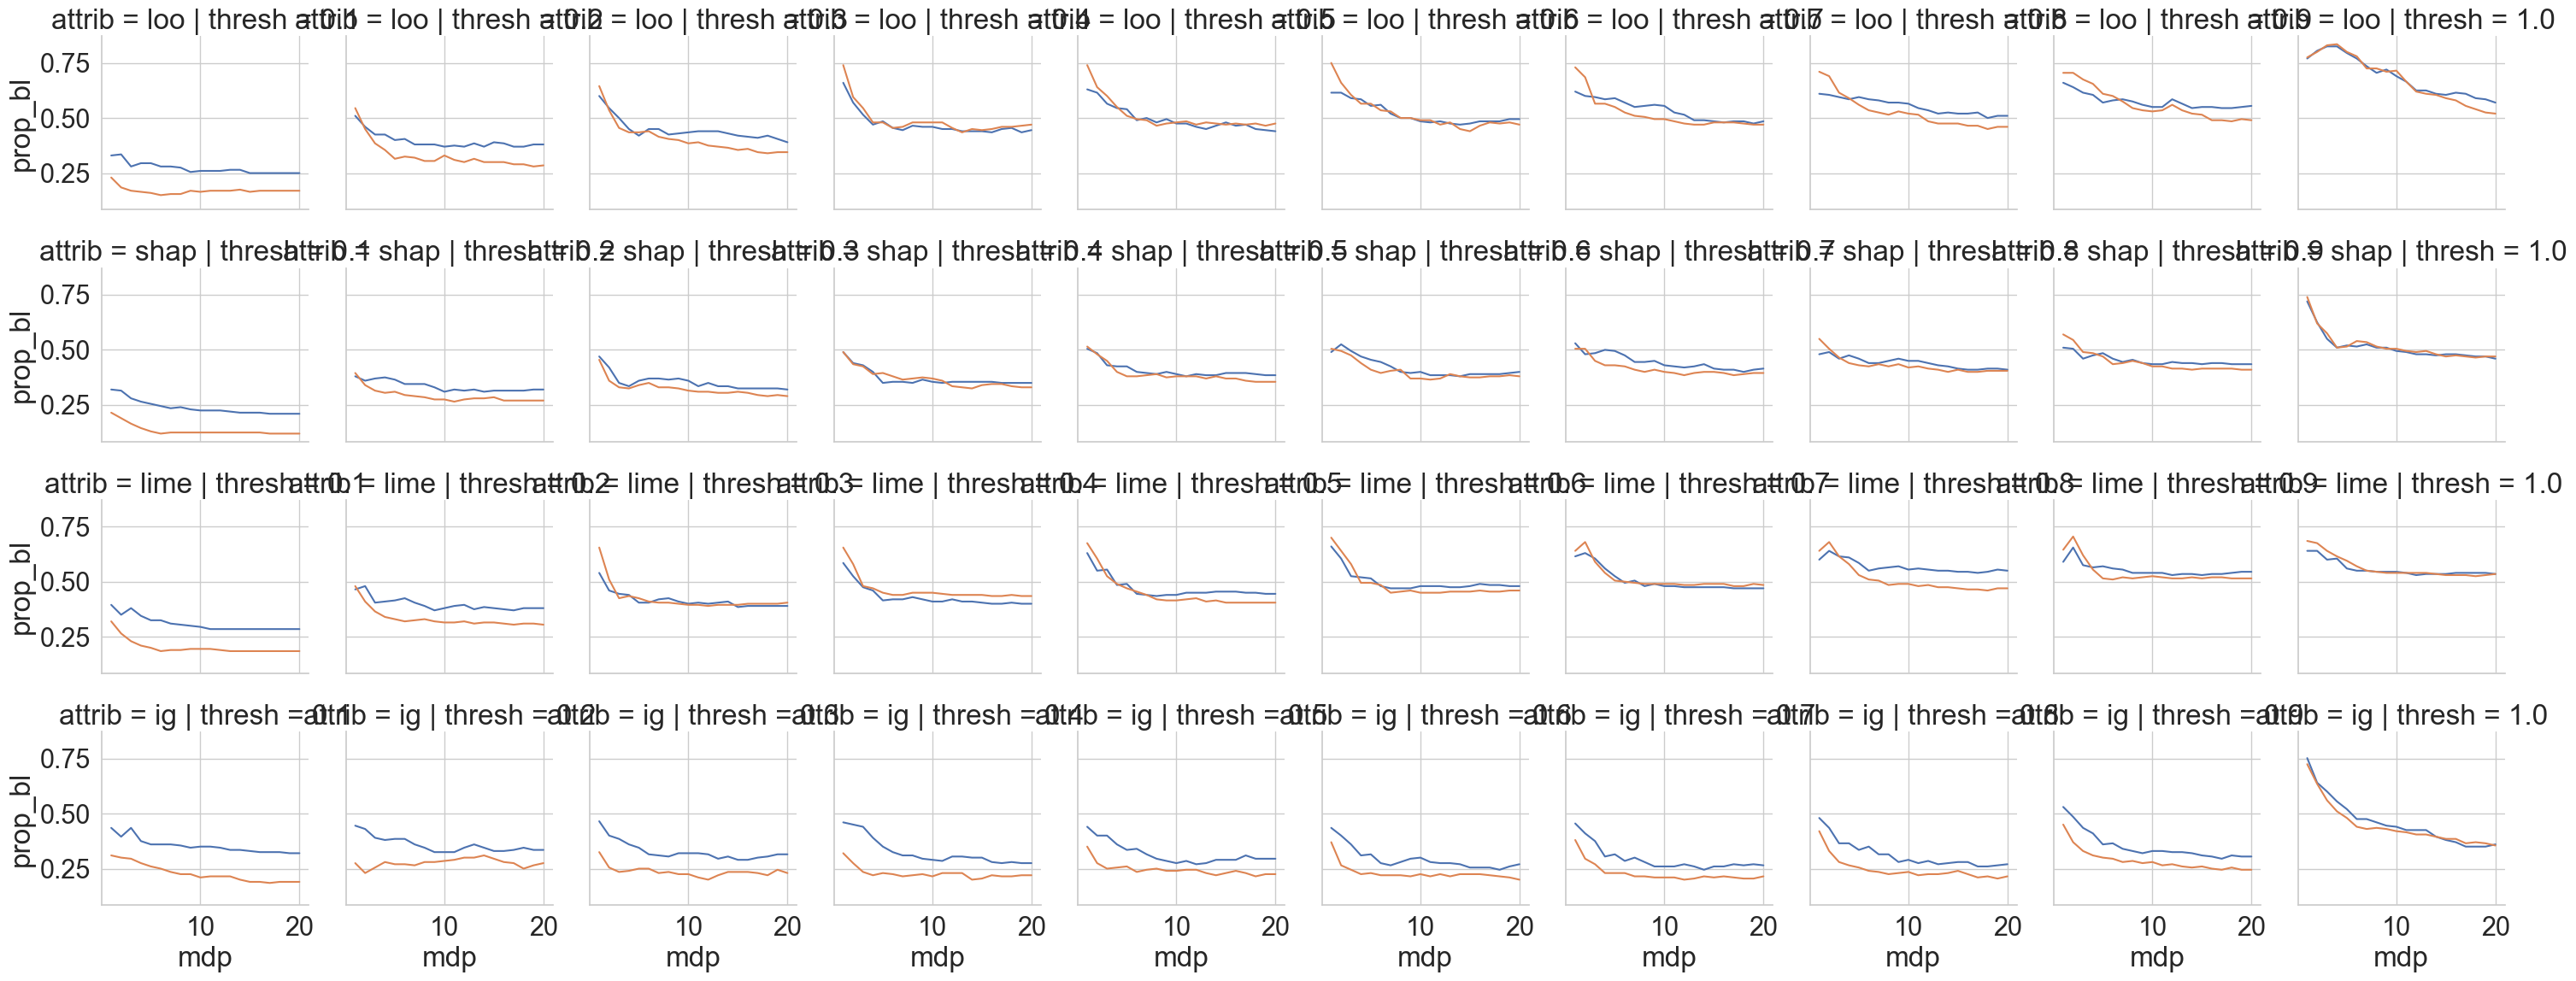

In [86]:
df['norm_setup'] =  df.apply(lambda row: row['docnorm'] + row['tfidf'], axis=1)
g = sns.FacetGrid(data=df[df.docnorm == 'T'], row='attrib', col='thresh', hue='norm_setup')
g.map(sns.lineplot, 'mdp', 'prop_bl')

<Axes: xlabel='thresh', ylabel='prop_lt5'>

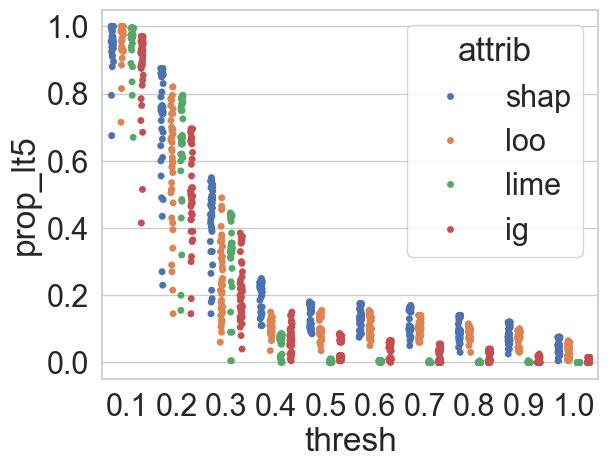

In [87]:
sns.stripplot(data=df[df.docnorm == 'T'], hue='attrib', x='thresh', y='prop_lt5', dodge=True)

In [88]:
df1['Group'] = 'Scandi.'
df2['Group'] = 'EV'
df3['Group'] = 'CS'
df = pd.concat([df1, df2, df3]).groupby(['Group', 'attrib', 'thresh']).mean(numeric_only=True).reset_index()
df['1'] = df['prop_happaxes']
df['2'] = df['prop_lt2'] - df['1']
df['3'] = df['prop_lt3'] - df['2'] - df['1']
df['4'] = df['prop_lt4'] - df['3'] - df['2'] - df['1']
df['5'] = df['prop_lt5'] - df['4'] - df['3'] - df['2'] - df['1']
df['6+'] = 1 - df['5'] - df['4'] - df['3'] - df['2'] - df['1']

df = df.melt(
    id_vars=['Group', 'attrib', 'thresh'], 
    value_vars=['1', '2', '3', '4', '5', '6+'][::-1], 
    value_name='prop', 
    var_name='freq',
).rename(columns={'attrib': 'Attribution'})
df

,Group,Attribution,thresh,freq,prop
0,CS,ig,0.1,6+,0.557813
1,CS,ig,0.2,6+,0.743375
2,CS,ig,0.3,6+,0.888750
3,CS,ig,0.4,6+,0.962687
4,CS,ig,0.5,6+,0.977125
...,...,...,...,...,...
715,Scandi.,shap,0.6,1,0.000000
716,Scandi.,shap,0.7,1,0.000000
717,Scandi.,shap,0.8,1,0.000000
718,Scandi.,shap,0.9,1,0.000000


In [89]:
alt.Chart(df[df.Attribution == 'loo']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

alt.Chart(...)

In [90]:
alt.Chart(df[df.Attribution == 'ig']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

alt.Chart(...)

In [91]:
alt.Chart(df[df.Attribution == 'shap']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

alt.Chart(...)

In [92]:
alt.Chart(df[df.Attribution == 'lime']).mark_bar().encode(
    x=alt.X('thresh:O', title=None),
    y=alt.Y('prop:Q', axis=alt.Axis(grid=False, title=None)),
    column=alt.Column('Group:N', title=None),
    color=alt.Color('freq:O') #, scale=alt.Scale(range=['#96ceb4', '#ffcc5c','#ff6f69']))
).configure_view(
    strokeOpacity=0    
)

alt.Chart(...)